<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/IntoInfinity006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IntoInfinity006 — Core Setup

import numpy as np

# =========================
# 1. Harmonic anchor
# =========================
N_TARGET = 100.0
ANCHOR = np.array([0.0, 0.0, N_TARGET], dtype=float)

def direction_unit(v):
    mag = np.linalg.norm(v)
    return v / mag if mag != 0 else v

ANCHOR_DIR = direction_unit(ANCHOR)

# =========================
# 2. Operators (same as 005)
# =========================

def op_logistic(v):
    a, b, n = v
    return np.array([
        a * (1 - a/100),
        b * (1 - b/100),
        n * 1.05
    ])

def op_piecewise(v):
    a, b, n = v
    return np.array([
        a/2 if a > 0 else a*2,
        b/2 if b > 0 else b*2,
        n * 1.08
    ])

def op_lorenz(v):
    a, b, n = v
    return np.array([
        a + 0.1*(b - a),
        b + (a*(28 - n) - b),
        n + (a*b - (8/3)*n)
    ])

OPERATORS = {
    "logistic": op_logistic,
    "piecewise": op_piecewise,
    "lorenz": op_lorenz,
}

# =========================
# 3. Normalisation
# =========================

def norm_to_N(v, N=N_TARGET):
    mag = np.linalg.norm(v)
    return v * (N/mag) if mag != 0 else v

# =========================
# 4. Iteration engine
# =========================

def iterate(v0, op, steps=200, normalised=False):
    v = v0.copy()
    traj = [v.copy()]
    for _ in range(steps):
        v = op(v)
        if normalised:
            v = norm_to_N(v)
        traj.append(v.copy())
    return traj


In [2]:
# IntoInfinity006 — Single perturbation test

# Small random perturbation around (0,0,100)
eps = 0.5
delta = np.random.uniform(-eps, eps, size=3)
v0 = ANCHOR + delta

print("Initial perturbed vector:", v0)

results = {}

for name, op in OPERATORS.items():
    traj_raw = iterate(v0, op, normalised=False)
    traj_norm = iterate(v0, op, normalised=True)

    results[name] = {
        "raw_final": traj_raw[-1],
        "norm_final": traj_norm[-1],
        "raw_dir": direction_unit(traj_raw[-1]),
        "norm_dir": direction_unit(traj_norm[-1]),
    }

print("\n=== RESULTS ===")
for name, r in results.items():
    print(f"\nOperator: {name}")
    print("  Raw final:", r["raw_final"])
    print("  Raw direction:", r["raw_dir"])
    print("  Norm final:", r["norm_final"])
    print("  Norm direction:", r["norm_dir"])


Initial perturbed vector: [ 0.48516211 -0.36708206 99.92250955]

=== RESULTS ===

Operator: logistic
  Raw final: [ 2.45822402e-01 -1.35646894e+00  1.72791807e+06]
  Raw direction: [ 1.42265080e-07 -7.85030817e-07  1.00000000e+00]
  Norm final: [ 2.54743777e-05 -2.30162198e-05  1.00000000e+02]
  Norm direction: [ 2.54743777e-07 -2.30162198e-07  1.00000000e+00]

Operator: piecewise
  Raw final: [ 3.01917122e-61 -5.89878122e+59  4.83519986e+08]
  Raw direction: [ 5.11829666e-121 -1.00000000e+000  8.19694726e-052]
  Norm final: [ 5.11829666e-119 -1.00000000e+002  8.19694726e-050]
  Norm direction: [ 5.11829666e-121 -1.00000000e+000  8.19694726e-052]

Operator: lorenz
  Raw final: [nan nan nan]
  Raw direction: [nan nan nan]
  Norm final: [  0.32246474 -63.4274335  -77.31013321]
  Norm direction: [ 0.00322465 -0.63427433 -0.77310133]


/tmp/ipykernel_1951/1530190077.py:41: RuntimeWarning: overflow encountered in scalar multiply
  b + (a*(28 - n) - b),
/tmp/ipykernel_1951/1530190077.py:42: RuntimeWarning: overflow encountered in scalar multiply
  n + (a*b - (8/3)*n)
/tmp/ipykernel_1951/1530190077.py:41: RuntimeWarning: invalid value encountered in scalar subtract
  b + (a*(28 - n) - b),
/tmp/ipykernel_1951/1530190077.py:42: RuntimeWarning: invalid value encountered in scalar add
  n + (a*b - (8/3)*n)


In [3]:
# IntoInfinity006 — Cell 3
# Sweep of random perturbations and direction classification

def classify_direction(v):
    """Return which axis/direction the vector aligns with."""
    d = direction_unit(v)
    ax = np.abs(d)

    # anchor direction = +N axis
    if np.linalg.norm(d - ANCHOR_DIR) < 1e-3:
        return "anchor"

    # negative N axis
    if np.linalg.norm(d + ANCHOR_DIR) < 1e-3:
        return "-n"

    # pure a or b axis
    if ax[0] > 0.9:
        return "a-axis"
    if ax[1] > 0.9:
        return "b-axis"

    return "mixed"

results = {op: [] for op in OPERATORS}

for op_name, op in OPERATORS.items():
    for _ in range(200):
        delta = np.random.uniform(-1, 1, size=3)
        v0 = ANCHOR + delta
        traj = iterate(v0, op, normalised=True)
        final = traj[-1]
        results[op_name].append(classify_direction(final))

# Print summary
from collections import Counter

for op_name in OPERATORS:
    print("\n=== Operator:", op_name, "===")
    c = Counter(results[op_name])
    for k, v in c.items():
        print(f"{k:10s} : {v}")



=== Operator: logistic ===
anchor     : 200

=== Operator: piecewise ===
anchor     : 37
b-axis     : 65
a-axis     : 72
mixed      : 26

=== Operator: lorenz ===
mixed      : 170
b-axis     : 30


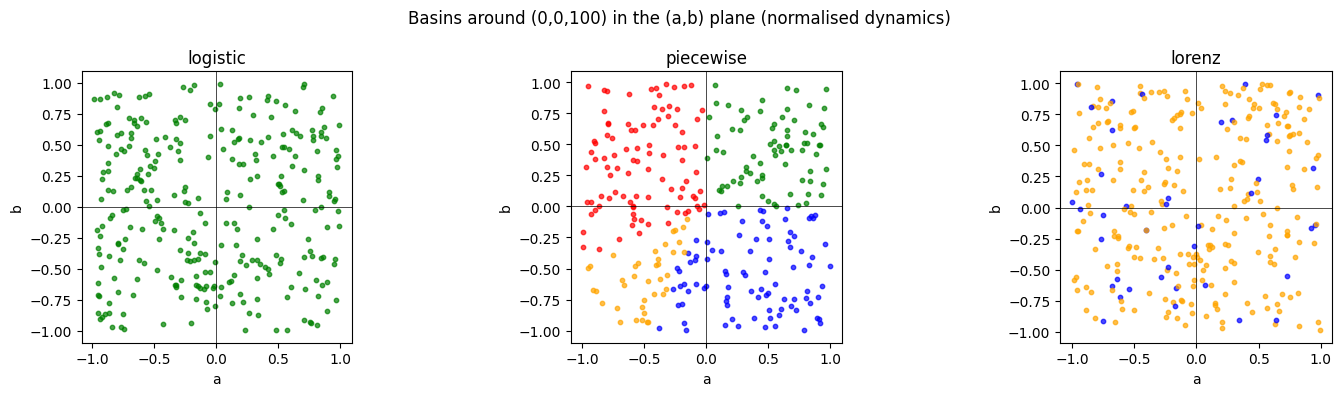

In [4]:
# IntoInfinity006 — Cell 4
# Visualise initial perturbations coloured by outcome (normalised dynamics)

import matplotlib.pyplot as plt

def classify_direction_full(v):
    d = direction_unit(v)
    ax = np.abs(d)

    if np.linalg.norm(d - ANCHOR_DIR) < 1e-3:
        return "anchor"
    if np.linalg.norm(d + ANCHOR_DIR) < 1e-3:
        return "-n"
    if ax[0] > 0.9:
        return "a-axis"
    if ax[1] > 0.9:
        return "b-axis"
    return "mixed"

def sweep_and_collect(op_name, op, n_samples=300):
    pts = []
    labels = []
    for _ in range(n_samples):
        delta = np.random.uniform(-1, 1, size=3)
        v0 = ANCHOR + delta
        traj = iterate(v0, op, normalised=True)
        final = traj[-1]
        label = classify_direction_full(final)
        pts.append(v0)
        labels.append(label)
    return np.array(pts), labels

color_map = {
    "anchor": "green",
    "a-axis": "red",
    "b-axis": "blue",
    "mixed": "orange",
    "-n": "purple",
}

plt.figure(figsize=(15, 4))

for i, (name, op) in enumerate(OPERATORS.items()):
    pts, labels = sweep_and_collect(name, op)
    plt.subplot(1, 3, i+1)
    for p, lab in zip(pts, labels):
        a, b, n = p
        plt.scatter(a, b, s=10, color=color_map.get(lab, "black"), alpha=0.7)
    plt.axhline(0, color="k", linewidth=0.5)
    plt.axvline(0, color="k", linewidth=0.5)
    plt.title(name)
    plt.xlabel("a")
    plt.ylabel("b")
    plt.gca().set_aspect("equal", "box")

plt.suptitle("Basins around (0,0,100) in the (a,b) plane (normalised dynamics)")
plt.tight_layout()
plt.show()


In [5]:
# IntoInfinity006 — Cell 5
# Compute attractor directions for each operator via repeated normalised iteration

def find_attractor_direction(op, iters=2000):
    v = np.array([1.0, 1.0, 1.0])  # generic non-aligned start
    for _ in range(iters):
        v = op(v)
        v = norm_to_N(v)
    return direction_unit(v)

print("=== Attractor directions (normalised) ===")
for name, op in OPERATORS.items():
    d = find_attractor_direction(op)
    print(f"{name:10s} -> {d}")


=== Attractor directions (normalised) ===
logistic   -> [1.84331544e-44 1.84331544e-44 1.00000000e+00]
piecewise  -> [0. 0. 1.]
lorenz     -> [ 0.09146509 -0.57255338  0.81474951]


In [6]:
# IntoInfinity006 — Cell 6
# Angle between each attractor direction and the harmonic anchor

def angle_between(u, v):
    u = direction_unit(u)
    v = direction_unit(v)
    dot = np.clip(np.dot(u, v), -1.0, 1.0)
    return np.degrees(np.arccos(dot))

anchor_dir = ANCHOR_DIR

print("=== Angle to harmonic anchor (degrees) ===")
for name, op in OPERATORS.items():
    d = find_attractor_direction(op)
    ang = angle_between(d, anchor_dir)
    print(f"{name:10s} -> {ang:.6f}°  | dir = {d}")


=== Angle to harmonic anchor (degrees) ===
logistic   -> 0.000000°  | dir = [1.84331544e-44 1.84331544e-44 1.00000000e+00]
piecewise  -> 0.000000°  | dir = [0. 0. 1.]
lorenz     -> 35.437399°  | dir = [ 0.09146509 -0.57255338  0.81474951]


In [7]:
# IntoInfinity006 — Cell 7
# Lorenz-only deep dive: direction convergence from many random initial vectors

def lorenz_direction_from(v0, steps=2000):
    v = v0.copy()
    for _ in range(steps):
        v = op_lorenz(v)
        v = norm_to_N(v)
    return direction_unit(v)

samples = 200
dirs = []

for _ in range(samples):
    # random initial vector not aligned with anchor
    v0 = np.random.uniform(-5, 5, size=3)
    dirs.append(lorenz_direction_from(v0))

dirs = np.array(dirs)

print("First 10 converged directions:")
print(dirs[:10])
print("\nMean direction:", np.mean(dirs, axis=0))
print("Std direction:", np.std(dirs, axis=0))


First 10 converged directions:
[[-0.00302489  0.58400464 -0.81174468]
 [ 0.08716496 -0.54099895  0.83649412]
 [-0.0871234   0.54531823  0.83368912]
 [ 0.00498754 -0.75316556 -0.65781211]
 [ 0.00454737 -0.72566287 -0.68803541]
 [ 0.08753513 -0.5882475   0.8039294 ]
 [-0.00242373  0.55075604 -0.83466275]
 [ 0.07601988 -0.49139664  0.86761185]
 [-0.05889115  0.35842147  0.93170053]
 [-0.07230456  0.32167313  0.94408604]]

Mean direction: [ 0.00431671 -0.00865519  0.22314225]
Std direction: [0.05663721 0.56085754 0.79520125]


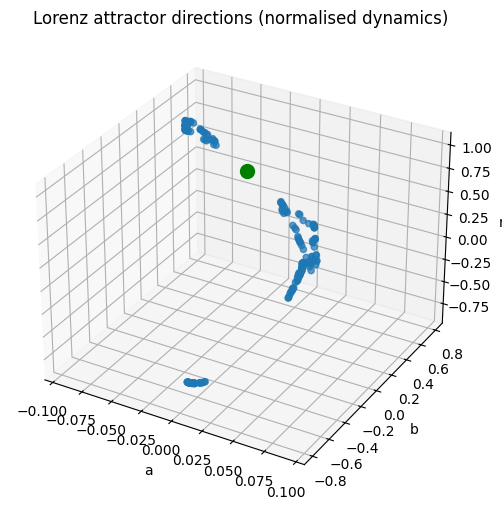

In [8]:
# IntoInfinity006 — Cell 8
# Scatter plot of Lorenz attractor directions on the unit sphere

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = dirs[:,0], dirs[:,1], dirs[:,2]

ax.scatter(xs, ys, zs, s=20, alpha=0.7)

# draw anchor direction for reference
ax.scatter([0], [0], [1], color='green', s=100)

ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("n")
ax.set_title("Lorenz attractor directions (normalised dynamics)")

plt.show()


In [9]:
# IntoInfinity006 — Cell 9
# Stability test: perturb the Lorenz attractor direction slightly and re-run

base_dir = find_attractor_direction(op_lorenz)

perturbed_dirs = []

for _ in range(100):
    delta = np.random.normal(0, 0.01, size=3)
    v0 = base_dir + delta
    perturbed_dirs.append(lorenz_direction_from(v0))

perturbed_dirs = np.array(perturbed_dirs)

print("Mean perturbed direction:", np.mean(perturbed_dirs, axis=0))
print("Std perturbed direction:", np.std(perturbed_dirs, axis=0))


Mean perturbed direction: [-0.00281477 -0.03866598  0.06772443]
Std perturbed direction: [0.04955196 0.57800818 0.81077837]


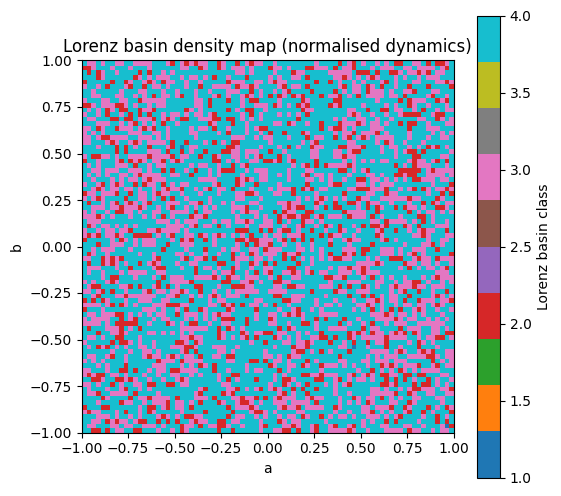

In [10]:
# IntoInfinity006 — Cell 10
# Lorenz basin density map in the (a,b) plane

import numpy as np
import matplotlib.pyplot as plt

def lorenz_class(v):
    d = direction_unit(v)
    ax = np.abs(d)
    if ax[0] > 0.9:
        return "a"
    if ax[1] > 0.9:
        return "b"
    if ax[2] > 0.9:
        return "n"
    return "mixed"

grid = 80
a_vals = np.linspace(-1, 1, grid)
b_vals = np.linspace(-1, 1, grid)

density = np.zeros((grid, grid))

for i, a in enumerate(a_vals):
    for j, b in enumerate(b_vals):
        v0 = np.array([a, b, 100.0])
        traj = iterate(v0, op_lorenz, normalised=True)
        final = traj[-1]
        cls = lorenz_class(final)
        if cls == "a":
            density[j, i] = 1
        elif cls == "b":
            density[j, i] = 2
        elif cls == "n":
            density[j, i] = 3
        else:
            density[j, i] = 4

plt.figure(figsize=(6,6))
plt.imshow(density, extent=[-1,1,-1,1], origin='lower', cmap='tab10')
plt.colorbar(label="Lorenz basin class")
plt.xlabel("a")
plt.ylabel("b")
plt.title("Lorenz basin density map (normalised dynamics)")
plt.show()


In [12]:
# IntoInfinity006 — Cell 11
# Directional entropy of Lorenz attractor directions

from scipy.spatial.distance import pdist, squareform

def lorenz_direction_samples(n=500):
    out = []
    for _ in range(n):
        v0 = np.random.uniform(-5, 5, size=3)
        out.append(lorenz_direction_from(v0))
    return np.array(out)

dirs = lorenz_direction_samples(500)

# pairwise angular distances
def angle(u, v):
    dot = np.clip(np.dot(u, v), -1, 1)
    return np.arccos(dot)

angles = []
for i in range(len(dirs)):
    for j in range(i+1, len(dirs)):
        angles.append(angle(dirs[i], dirs[j]))

angles = np.array(angles)

# histogram entropy
hist, bins = np.histogram(angles, bins=40, density=True)
hist = hist[hist > 0]
entropy = -np.sum(hist * np.log(hist))

print("Directional entropy:", entropy)
print("Mean pairwise angle:", np.mean(angles))
print("Std pairwise angle:", np.std(angles))


Directional entropy: 11.630955996770673
Mean pairwise angle: 1.496713319238173
Std pairwise angle: 1.004146524783811


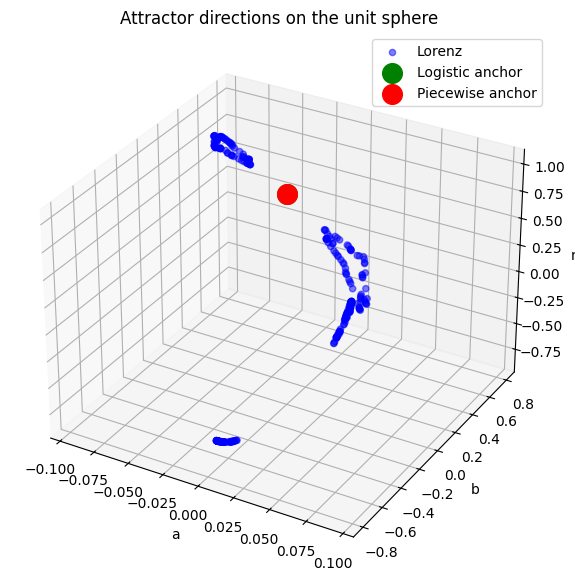

In [13]:
# IntoInfinity006 — Cell 12
# Compare logistic, piecewise, and Lorenz attractor directions on the unit sphere

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def attractor_dir(op):
    return find_attractor_direction(op)

log_dir = attractor_dir(op_logistic)
pie_dir = attractor_dir(op_piecewise)
lor_dirs = lorenz_direction_samples(300)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Lorenz cloud
ax.scatter(lor_dirs[:,0], lor_dirs[:,1], lor_dirs[:,2],
           s=20, alpha=0.5, color='blue', label='Lorenz')

# Logistic + Piecewise anchors
ax.scatter([log_dir[0]], [log_dir[1]], [log_dir[2]],
           color='green', s=200, label='Logistic anchor')

ax.scatter([pie_dir[0]], [pie_dir[1]], [pie_dir[2]],
           color='red', s=200, label='Piecewise anchor')

ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("n")
ax.set_title("Attractor directions on the unit sphere")
ax.legend()
plt.show()
